# 03 — ユーザー指令・2点参照・Gait

## 目的
人の速度指令をNMPC参照へ変換する過程と、接地scheduleが別経路である理由を理解する。

実装対応:
- [`TargetTrajectoriesPublisher.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_controllers/src/TargetTrajectoriesPublisher.cpp)
- `legged_controllers/config/a1/reference.info`
- `legged_controllers/config/a1/gait.info`


## 検証範囲に関する必須注記

このprojectでは **ROS2 portを作成・compile・実行していない**。したがってROS2 parityは
**NOT VERIFIED / FAIL-CLOSED** である。上流commit `a7f381c0367e98e31c01336e678eef47e304d40d` はROS1実装であり、
project所有MuJoCo adapterはOCS2のhorizon SQPを瞬時force plannerへ、
Pinocchio/qpOASES WBCをMuJoCo acceleration inverse dynamicsへ置換し、
元のestimator/hardware経路も持たない。保存済み30 scenario dataが示すのはadapter挙動だけで、
上流 `legged_control` の性能でもROS2移行の検証でもない。


In [1]:
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`from pathlib import Path` の依存を明示して再現可能な実行環境を作る。
from pathlib import Path
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`import numpy as np` の依存を明示して再現可能な実行環境を作る。
import numpy as np
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`import matplotlib.pyplot as plt` の依存を明示して再現可能な実行環境を作る。
import matplotlib.pyplot as plt

# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`ROOT` を後続計算で使う明示的な中間量として設定する。 数式: `ROOT = Path.cwd()` の演算・変換をPythonで評価する。
ROOT = Path.cwd()
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`for candidate in [ROOT, *ROOT.parents]:` の反復範囲を固定して各sampleを処理する。 数式: `for candidate in [ROOT, *ROOT.parents]:` の演算・変換をPythonで評価する。
for candidate in [ROOT, *ROOT.parents]:
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`if (candidate / "pyproject.toml").exists():` の条件で安全側の実行分岐を選ぶ。 数式: `if (candidate / "pyproject.toml").exists():` の演算・変換をPythonで評価する。
    if (candidate / "pyproject.toml").exists():
        # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`ROOT` を後続計算で使う明示的な中間量として設定する。 数式: `ROOT = candidate` の演算・変換をPythonで評価する。
        ROOT = candidate
        # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`break` をこの章の処理順に沿って実行する。
        break

# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`np.set_printoptions(precision` を後続計算で使う明示的な中間量として設定する。 数式: `np.set_printoptions(precision=4, suppress=True)` の演算・変換をPythonで評価する。
np.set_printoptions(precision=4, suppress=True)
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、直前の式・構造へ `plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})` の要素または終端を対応付ける。
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`print("repository:", ROOT)` の観測値を表示して判定根拠を残す。
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


`/cmd_vel`で使うのは \([v_x,v_y,v_z,\dot\psi]\) の4成分。
並進速度を現在姿勢でworldへ回し、\(T=1.0\) s積分する。

\[
p_{xy}^{+}=p_{xy}+v_{W,xy}T,\qquad
\psi^+=\psi+\dot\psi T
\]

高さは `comHeight=0.3 m`、pitch/rollは0、関節参照はdefaultへ固定。
参照軌道は現在と1秒先の **2点だけ**で、区間内は線形補間される。


In [2]:
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`Rz` の責務を独立関数として定義する。
def Rz(yaw):
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`c, s` を後続計算で使う明示的な中間量として設定する。 数式: `c, s = np.cos(yaw), np.sin(yaw)` の演算・変換をPythonで評価する。
    c, s = np.cos(yaw), np.sin(yaw)
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])` の値を次の制御境界へ返す。 数式: `return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])` の演算・変換をPythonで評価する。
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`make_two_point_reference` の責務を独立関数として定義する。 数式: `def make_two_point_reference(pose, cmd, horizon=1.0, com_height=0.30):` の演算・変換をPythonで評価する。
def make_two_point_reference(pose, cmd, horizon=1.0, com_height=0.30):
    # pose = [x,y,z,yaw,pitch,roll], cmd = [vx,vy,vz,yaw_rate]
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`yaw` を後続計算で使う明示的な中間量として設定する。 数式: `yaw = pose[3]` の演算・変換をPythonで評価する。
    yaw = pose[3]
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`v_world` を後続計算で使う明示的な中間量として設定する。 数式: `v_world = Rz(yaw) @ np.asarray(cmd[:3])` の演算・変換をPythonで評価する。
    v_world = Rz(yaw) @ np.asarray(cmd[:3])
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`target` を後続計算で使う明示的な中間量として設定する。 数式: `target = np.asarray(pose, dtype=float).copy()` の演算・変換をPythonで評価する。
    target = np.asarray(pose, dtype=float).copy()
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`target[:2] +` を後続計算で使う明示的な中間量として設定する。 数式: `target[:2] += v_world[:2] * horizon` の演算・変換をPythonで評価する。
    target[:2] += v_world[:2] * horizon
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`target[2]` を後続計算で使う明示的な中間量として設定する。 数式: `target[2] = com_height` の演算・変換をPythonで評価する。
    target[2] = com_height
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`target[3] +` を後続計算で使う明示的な中間量として設定する。 数式: `target[3] += cmd[3] * horizon` の演算・変換をPythonで評価する。
    target[3] += cmd[3] * horizon
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`target[4:]` を後続計算で使う明示的な中間量として設定する。 数式: `target[4:] = 0.0` の演算・変換をPythonで評価する。
    target[4:] = 0.0
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`return np.array([0.0, horizon]), np.vstack([pose, target]), v_world` の値を次の制御境界へ返す。 数式: `return np.array([0.0, horizon]), np.vstack([pose, target]), v_world` の演算・変換をPythonで評価する。
    return np.array([0.0, horizon]), np.vstack([pose, target]), v_world

# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`pose` を後続計算で使う明示的な中間量として設定する。 数式: `pose = np.array([0, 0, 0.30, np.deg2rad(30), 0, 0], dtype=float)` の演算・変換をPythonで評価する。
pose = np.array([0, 0, 0.30, np.deg2rad(30), 0, 0], dtype=float)
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`times, poses, v_world` を後続計算で使う明示的な中間量として設定する。 数式: `times, poses, v_world = make_two_point_reference(pose, [0.5, 0, 0, 0.2])` の演算・変換をPythonで評価する。
times, poses, v_world = make_two_point_reference(pose, [0.5, 0, 0, 0.2])
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`print("times:", times)` の観測値を表示して判定根拠を残す。
print("times:", times)
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`print("world velocity:", v_world)` の観測値を表示して判定根拠を残す。
print("world velocity:", v_world)
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`print("pose endpoints:\n", poses)` の観測値を表示して判定根拠を残す。
print("pose endpoints:\n", poses)


times: [0. 1.]
world velocity: [0.433 0.25  0.   ]
pose endpoints:
 [[0.     0.     0.3    0.5236 0.     0.    ]
 [0.433  0.25   0.3    0.7236 0.     0.    ]]


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12399 (\N{HIRAGANA LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21442 (\N{CJK UNIFIED IDEOGRAPH-53C2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWar

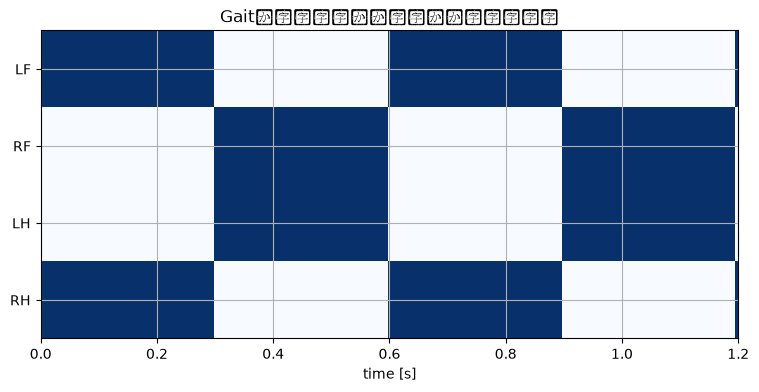

In [3]:
# trot: 0.0–0.3 sはLF/RH、0.3–0.6 sはRF/LH。
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`leg_names` を後続計算で使う明示的な中間量として設定する。 数式: `leg_names = np.array(["LF", "RF", "LH", "RH"])` の演算・変換をPythonで評価する。
leg_names = np.array(["LF", "RF", "LH", "RH"])
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`trot_contact` の責務を独立関数として定義する。
def trot_contact(t):
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`phase` を後続計算で使う明示的な中間量として設定する。 数式: `phase = np.mod(t, 0.6)` の演算・変換をPythonで評価する。
    phase = np.mod(t, 0.6)
    # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`return np.array([1, 0, 0, 1], dtype=bool) if phase < 0.3 else np.array([…` の値を次の制御境界へ返す。 数式: `return np.array([1, 0, 0, 1], dtype=bool) if phase < 0.3 else np.array([…` の演算・変換をPythonで評価する。
    return np.array([1, 0, 0, 1], dtype=bool) if phase < 0.3 else np.array([0, 1, 1, 0], dtype=bool)

# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`ts` を後続計算で使う明示的な中間量として設定する。 数式: `ts = np.linspace(0, 1.2, 241)` の演算・変換をPythonで評価する。
ts = np.linspace(0, 1.2, 241)
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`contacts` を後続計算で使う明示的な中間量として設定する。 数式: `contacts = np.array([trot_contact(t) for t in ts]).T` の演算・変換をPythonで評価する。
contacts = np.array([trot_contact(t) for t in ts]).T
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`fig, ax` を後続計算で使う明示的な中間量として設定する。 数式: `fig, ax = plt.subplots()` の演算・変換をPythonで評価する。
fig, ax = plt.subplots()
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`ax.imshow(contacts, aspect` を後続計算で使う明示的な中間量として設定する。 数式: `ax.imshow(contacts, aspect="auto", interpolation="nearest",` の演算・変換をPythonで評価する。
ax.imshow(contacts, aspect="auto", interpolation="nearest",
          # 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、`extent` を後続計算で使う明示的な中間量として設定する。 数式: `extent=[ts[0], ts[-1], 3.5, -0.5], cmap="Blues")` の演算・変換をPythonで評価する。
          extent=[ts[0], ts[-1], 3.5, -0.5], cmap="Blues")
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、直前の式・構造へ `ax.set_yticks(range(4), leg_names)` の要素または終端を対応付ける。
ax.set_yticks(range(4), leg_names)
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、直前の式・構造へ `ax.set_xlabel("time [s]")` の要素または終端を対応付ける。
ax.set_xlabel("time [s]")
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、直前の式・構造へ `ax.set_title("Gaitは速度参照とは独立した接地時間割")` の要素または終端を対応付ける。
ax.set_title("Gaitは速度参照とは独立した接地時間割")
# 背景: 速度参照と接地scheduleは別経路で届く。目的: 参照変換とgait生成を数値で追跡するため、直前の式・構造へ `plt.show()` の要素または終端を対応付ける。
plt.show()


## コード上の注意
`latestObservation_.time == 0` の間は指令を捨てる。初期観測なしに参照を作らない。
`goal`経路は距離と上限速度から到達時刻を決め、速度経路と違って運動量参照をゼロにする。

### 変更課題
- horizonを2秒にするだけでは、solver負荷と参照到達時間が同時に変わる。
- 速度に応じて自動でtrotへ切替える機能は現行標準経路にはない。
- 地形に応じた高さ参照も現行にはない。追加時はframeと地形基準を明示する。


## 章固有の背景
                速度目標と接地modeは異なる意思決定であり、一緒に自動生成されるとは限らない。

                ## 章固有の目的
                `cmd_vel`から2点TargetTrajectoriesを作る式と、独立GaitSchedule経路を追う。

                ## この章のASCIIデータフロー
                ```text
                /cmd_vel -> cmdVelToTargetTrajectories -> [t0,t1],[x0,x1]
gait name -> GaitReceiver -> ModeSchedule ------------------+-> OCP reference manager
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_controllers/src/TargetTrajectoriesPublisher.cpp
cmdVelRot = R_zyx * cmdVel.head(3);       // v_W = R_WB v_B
target.x += cmdVelRot.x() * T;            // x^+ = x + v_Wx T
target.y += cmdVelRot.y() * T;            // y^+ = y + v_Wy T
target.yaw += cmdVel(3) * T;              // psi^+ = psi + yawRate T
stateTrajectory[0].head(3)=cmdVelRot;     // h_linear/m reference
stateTrajectory[1].head(3)=cmdVelRot;
// GaitReceiver: gait command -> GaitSchedule::insertModeSequenceTemplate(...)
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                参照publisherは1秒先のposeを作るがgaitを選ばない。GaitReceiverが別topicからModeScheduleを更新する。
